In [7]:
from pathlib import Path
import sys
import re
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
folder = Path('/Users/samiraisin/Devil_semelparity_project/store_results/31.03.2026 100runs_0_sexual_infectivity/snapshots')

In [4]:
for f in folder.iterdir():
    print(f.name if 'mc_' in f.name else '')

mc_00018__sample_000__seed_12363__INFECTIVITY1_0.50000__INFECTIVITY2_0.05000_statistics
mc_00013__sample_000__seed_12358__INFECTIVITY1_0.50000__INFECTIVITY2_0.15000_statistics
mc_00020__sample_000__seed_12365__INFECTIVITY1_0.10000__INFECTIVITY2_0.05000_statistics
mc_00025__sample_000__seed_12370__INFECTIVITY1_0.45000__INFECTIVITY2_0.05000_statistics
mc_00015__sample_000__seed_12360__INFECTIVITY1_0.15000__INFECTIVITY2_0.25000_statistics
mc_00027__sample_000__seed_12372__INFECTIVITY1_0.45000__INFECTIVITY2_0.15000_statistics
mc_00028__sample_000__seed_12373__INFECTIVITY1_0.35000__INFECTIVITY2_0.30000_statistics
mc_00001__sample_000__seed_12346__INFECTIVITY1_0.30000__INFECTIVITY2_0.25000_statistics
mc_00000__sample_000__seed_12345__INFECTIVITY1_0.35000__INFECTIVITY2_0.15000_statistics
mc_00026__sample_000__seed_12371__INFECTIVITY1_0.40000__INFECTIVITY2_0.05000_statistics
mc_00007__sample_000__seed_12352__INFECTIVITY1_0.15000__INFECTIVITY2_0.45000_statistics
mc_00019__sample_000__seed_12364

In [9]:
df = pd.DataFrame(columns=["INF1", "INF2", "sample", "result"])

In [11]:
for entry in folder.iterdir():
    if not entry.is_dir():
        continue

    match = re.search(
        r"sample_(\d+)__seed_\d+__INFECTIVITY_SEXUAL_([0-9.]+)__INFECTIVITY_NONSEXUAL_([0-9.]+)",
        entry.name
    )
    if not match:
        continue

    temp_sample = match.group(1)
    temp_inf1 = match.group(2)
    temp_inf2 = match.group(3)

    csv_files = list(entry.glob("*.csv"))
    if not csv_files:
        continue

    temp_df = pd.read_csv(csv_files[0])
    temp_result = temp_df["result"].iloc[-1]

    df = pd.concat([
        df,
        pd.DataFrame({
            "INF1": [temp_inf1],
            "INF2": [temp_inf2],
            "sample": [temp_sample],
            "result": [temp_result],
        })
    ], ignore_index=True)

In [12]:
df.to_csv("100runs_0_sexual_infectivity_31.03.2026_summary.csv", index=False)

In [15]:
len(df)

100

In [16]:
df["result"].value_counts()

result
semelparous    68
outOfTime      22
iteroparous    10
Name: count, dtype: int64

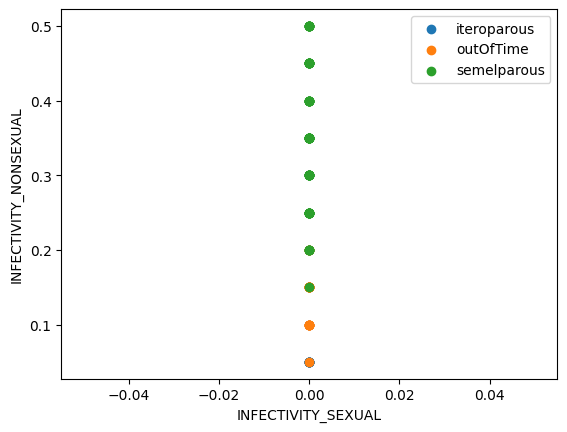

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = df.copy()
plot_df["INF1"] = pd.to_numeric(plot_df["INF1"], errors="coerce")
plot_df["INF2"] = pd.to_numeric(plot_df["INF2"], errors="coerce")
plot_df = plot_df.dropna(subset=["INF1", "INF2", "result"])

for result_name, g in plot_df.groupby("result"):
    plt.scatter(g["INF1"], g["INF2"], label=result_name)

plt.xlabel("INFECTIVITY_SEXUAL")
plt.ylabel("INFECTIVITY_NONSEXUAL")
plt.legend()
plt.show()

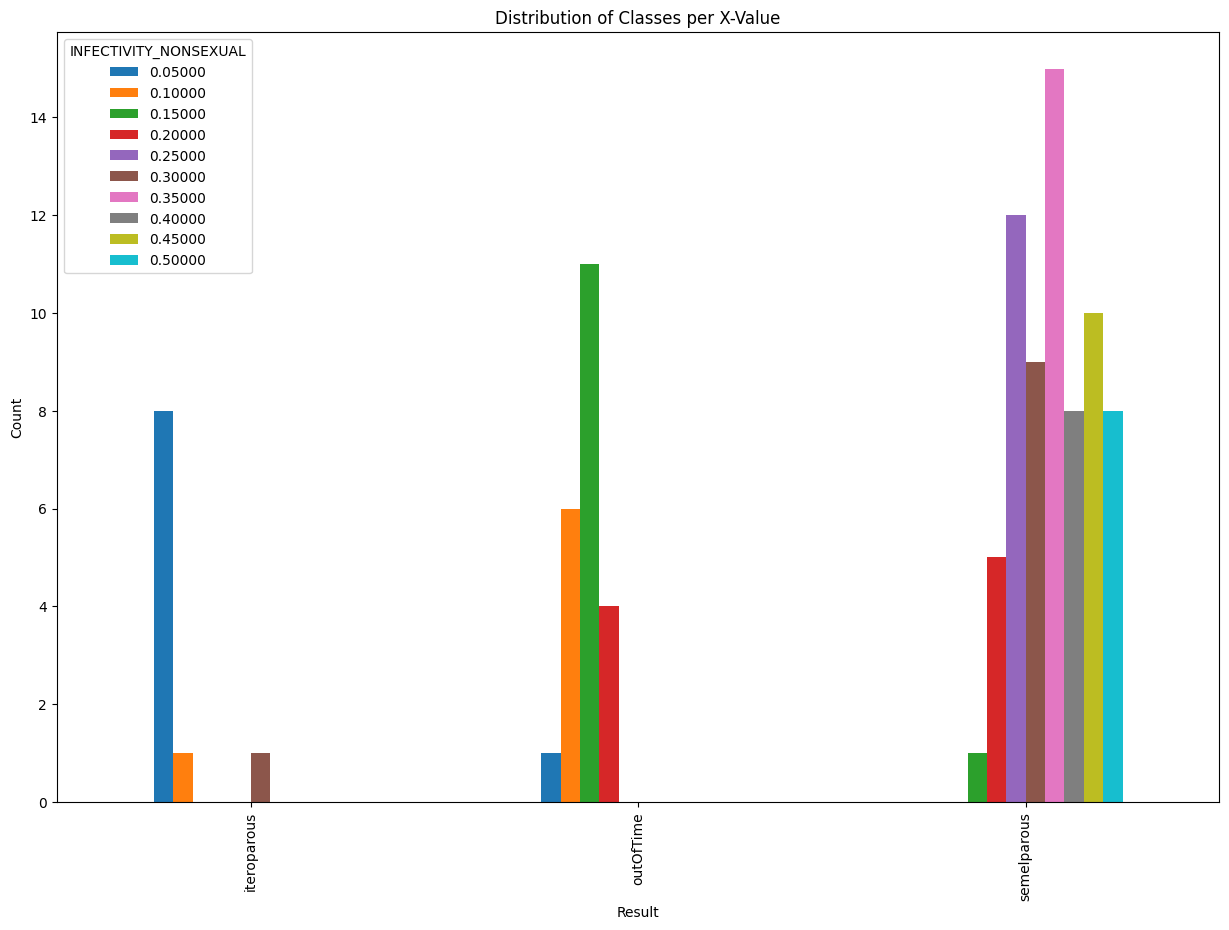

In [18]:
# 1. Create a frequency table (X-axis values vs Classes)
counts = pd.crosstab(df['result'], df['INF2'])

# 2. Plot as a grouped bar chart
counts.plot(kind='bar', figsize=(15, 10))

plt.title('Distribution of Classes per X-Value')
plt.xlabel('Result')
plt.ylabel('Count')
plt.legend(title='INFECTIVITY_NONSEXUAL')
plt.show()